# Assignment 2: Dynamic Programming — Policy Iteration & Value Iteration
**Prerequisites:** Complete Assignment 1 first (working GridWorld + policy_evaluation).
Read `lecture_notes.md` §6–7 before starting.

**Learning objectives:**
- Implement greedy policy improvement
- Implement full policy iteration (evaluation → improvement → repeat)
- Implement value iteration (max-Bellman backup)
- Compare convergence speed and verify both algorithms reach the same optimal policy

## Part 1: Theory Recap

**Policy Improvement Theorem:** Given $V^\pi$, define the greedy policy:

$$\pi'(s) = \arg\max_a \sum_{s'} P(s'|s,a)\bigl[R(s,a,s') + \gamma V^\pi(s')\bigr]$$

Then $V^{\pi'}(s) \ge V^\pi(s)$ for all $s$ (the new policy is at least as good).

**Bellman Optimality Operator** (used in value iteration):

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a)\bigl[R(s,a,s') + \gamma V^*(s')\bigr]$$

Value iteration applies this update repeatedly until $\max_s |V_{k+1}(s) - V_k(s)| < \theta$.
It converges because $\mathcal{T}$ is a $\gamma$-contraction (proved in lecture_notes Appendix).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

## Part 2: GridWorld (copy from Assignment 1)

Paste your completed `GridWorld` class here (with all methods implemented).
Assignment 2 builds directly on top of it — `policy_improvement`, `policy_iteration`,
and `value_iteration` all call `env.get_transitions`.

In [37]:
class GridWorld:
    """
    Configurable stochastic GridWorld MDP.

    Grid symbols:
        ' ' = empty cell
        'W' = wall (impassable; not a state)
        'G' = goal  (reward +1, terminal)
        'H' = hole  (reward -1, terminal)
        'S' = start (reward  0, non-terminal)

    Actions: 0=up, 1=right, 2=down, 3=left.

    Stochastic dynamics (slip > 0):
        With prob (1 - slip): take intended action.
        With prob slip/2:     move perpendicular left  (action - 1) % 4.
        With prob slip/2:     move perpendicular right (action + 1) % 4.

    If an action would move the agent into a wall or off the grid, the agent stays in place.
    """
    ACTIONS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    ACTION_NAMES = {0: '↑', 1: '→', 2: '↓', 3: '←'}

    def __init__(self, grid: List[List[str]], gamma: float = 0.99, slip: float = 0.0):
        """
        Parameters
        ----------
        grid  : 2-D list of strings (symbols defined above).
        gamma : discount factor ∈ [0, 1).
        slip  : probability of a perpendicular move ∈ [0, 1).
        """
        self.grid = np.array(grid)
        self.gamma = gamma
        self.slip = slip
        self.states = [(x,y) for x in range(len(grid)) for y in range(len(grid[0]))]

        self.n_cols = len(grid[0])
        self.n_rows = len(grid)

        self.terminal: set = set()
        self.walls: set = set()

        for r in range(self.n_rows):
            for c in range(self.n_cols):
                cell = grid[r][c]
                if cell == 'W':
                    self.walls.add((r, c))
                else:
                    if cell in ('G', 'H'):
                        self.terminal.add((r, c))

    def _reward(self, state: Tuple) -> float:
        """
        Return the immediate reward for *being in* `state`.

        +1.0 for goal 'G', -1.0 for hole 'H', 0.0 otherwise.
        """
        if self.grid[state] == 'G':
            return 1.0

        if self.grid[state] == 'H':
            return -1.0
            
        else:
            return 0.0

    def _next_state(self, state: Tuple, action: int) -> Tuple:
        """
        Return the deterministic next state when taking `action` from `state`.

        If the resulting position is out-of-bounds or a wall, return `state` unchanged
        (the agent bounces back).
        """
        new_state = list(state)
        
        new_state[0] += GridWorld.ACTIONS[action][0]
        new_state[1] += GridWorld.ACTIONS[action][1]

        if new_state[0] < 0 or new_state[0] >= len(self.grid):
            new_state = state

        if new_state[1] < 0 or new_state[1] >= len(self.grid[0]):
            new_state = state

        return tuple(new_state)

    def get_transitions(self, state: Tuple, action: int) -> List[Tuple[float, Tuple, float, bool]]:
        """
        Return the full transition distribution for (state, action).

        Returns a list of tuples: (probability, next_state, reward, done).

        Special cases:
        - If `state` is terminal, return [(1.0, state, 0.0, True)] — the episode is over,
          no reward is collected and the agent stays in the absorbing terminal state.
        - If slip == 0, the list has exactly one entry with probability 1.0.
        - If slip > 0, merge probabilities for identical next_states (so the list never has
          duplicate next_states).

        Steps to implement:
        1. Return early if state is terminal.
        2. Compute perpendicular actions: left = (action - 1) % 4, right = (action + 1) % 4.
        3. Build a raw list: [(1 - slip, intended), (slip/2, perp_left), (slip/2, perp_right)].
        4. For each (prob, act), compute next_state = self._next_state(state, act).
        5. Merge: accumulate probabilities for identical next_states into a dict, then convert
           back to a list of (prob, next_state, reward, done) tuples.
        6. reward = self._reward(next_state); done = next_state in self.terminal.
        """

        if self.grid[state[0]][state[1]] == 'G' or self.grid[state[0]][state[1]] == 'H':
            return [(1.0, state, 0.0, True)]

        p = 1.0
        next_states = {}
        
        if self.slip == 0:
            next_state = self._next_state(state, action)
            next_states[next_state] = next_states.get(next_state, 0.0) + p
            
        else:
            perp_left = (action - 1) % 4
            perp_right = (action + 1) % 4

            prob_ac = [(1-self.slip, action), (self.slip/2, perp_left), (self.slip/2, perp_right)]
            
            for pr,a in prob_ac:
                next_state = self._next_state(state, a)

                next_states[next_state] = next_states.get(next_state, 0.0) + pr

        res = []

        for n in next_states:
            reward = self._reward(n)
            done = self.grid[n] in self.terminal
            res.append((next_states[n], n, reward, done))
            
        return res
        

    def policy_evaluation(self, policy: Dict[Tuple, int], theta: float = 1e-8) -> Dict[Tuple, float]:
        """
        Iterative policy evaluation. Repeatedly apply:

            V(s) ← Σ_{s'} P(s'|s,π(s)) [R(s,π(s),s') + γ V(s')]

        until max_s |V_new(s) - V_old(s)| < theta.

        Returns V: dict mapping each state → float value.

        Common mistakes to avoid:
        - Do NOT update terminal states; their value is always 0.
        - Use the value from the *start* of the sweep (synchronous update), not in-place
          updates within a sweep — or equivalently, use in-place but track delta correctly.
          (Either synchronous or in-place/asynchronous converges; synchronous is cleaner.)

        Steps to implement:
        1. Initialize V = {s: 0.0 for s in self.states}.
        2. Outer loop: repeat until delta < theta.
        3. Inner loop: for each non-terminal state s, compute the Bellman update using
           self.get_transitions(s, policy[s]).
        4. Track delta = max over all states of |V_new(s) - V_old(s)|.
        5. Return V.
        """

        V = {s: 0.0 for s in self.states}

        iter_num = 0
        
        while True:
            
            delta = 0.0
            for s in self.states:
                new_V = 0.0
                
                if s not in self.terminal:
                    ns = self.get_transitions(s, policy[s])

                    for n in ns:
                        # print(n[0], n[2], n[1])
                        new_V += n[0] * (n[2] + self.gamma * V[n[1]])
                    delta = max(delta, abs(new_V - V[s]))

                V[s] = new_V
                
            iter_num += 1
            
            if delta < theta:
                # print("Theta breaked ", delta, iter_num)
                break
                
        return V

    def visualize_values(self,
                         V: Dict[Tuple, float],
                         policy: Optional[Dict[Tuple, int]] = None,
                         title: str = "Value Function"):
        """
        Visualize the value function as a heatmap. Optionally overlay policy arrows.

        Steps to implement:
        1. Create a 2-D numpy array `grid_vals` of shape (n_rows, n_cols) filled with np.nan.
        2. Fill in grid_vals[r][c] = V[(r,c)] for each non-wall, non-terminal state.
           Set terminal 'G' cells to +1.0 and 'H' cells to -1.0 for visual clarity.
        3. Use plt.imshow(grid_vals, cmap='RdYlGn', vmin=-1, vmax=1) for a red-yellow-green
           color scale (red = bad, green = good).
        4. Annotate each non-wall cell with its value (2 decimal places).
        5. If policy is provided, overlay ACTION_NAMES arrows on non-terminal states.
        6. Mark wall cells as black (set their alpha or fill with a black patch).
        7. Add title, colorbar, and plt.tight_layout(); call plt.show().
        """

        grid_vals = np.ones((len(self.grid), len(self.grid[0]))) * np.nan

        for s in V:
            # print(s, self.grid[s], V[s])
            if s not in self.terminal and self.grid[s] != 'W':
                grid_vals[s] = V[s]

            if self.grid[s] == 'G':
                grid_vals[s] = +1.0

            if self.grid[s] == 'H':
                grid_vals[s] = -1.0

        # print(grid_vals)

        fig, ax = plt.subplots(figsize=(self.n_cols * 1.2, self.n_rows * 1.2))
        im = ax.imshow(grid_vals, cmap='RdYlGn', vmin=-1, vmax=1, aspect='equal')

        # Mark walls black
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if (r, c) in self.walls:
                    ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color='black'))

        # Annotate cells
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                state = (r, c)
                if state in self.walls:
                    continue
                val = grid_vals[r,c]
                if not np.isnan(val):
                    ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                            fontsize=8, color='black')

        # Overlay policy arrows
        if policy is not None:
            for s in self.states:
                if s in self.terminal:
                    continue
                r, c = s
                if s in policy:
                    ax.text(c, r - 0.3, self.ACTION_NAMES[policy[s]],
                            ha='center', va='center', fontsize=12, color='navy')

        ax.set_title(title)
        ax.set_xticks(range(self.n_cols))
        ax.set_yticks(range(self.n_rows))
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()

        

## Part 3: Implementation — Policy Improvement and Policy Iteration

In [42]:
def policy_improvement(env: GridWorld, V: Dict[Tuple, float]) -> Dict[Tuple, int]:
    """
    Greedy policy improvement.

    For each non-terminal state, compute the action-value:
        Q(s, a) = Σ_{s'} P(s'|s,a) [R(s,a,s') + γ V(s')]

    Then set:
        π'(s) = argmax_a Q(s, a)

    For terminal states, return any fixed action (e.g., 0) — it does not matter because
    the episode ends immediately.

    Parameters
    ----------
    env : GridWorld instance (provides get_transitions, states, terminal, gamma).
    V   : dict mapping state → float value (result of policy_evaluation).

    Returns
    -------
    new_policy : dict mapping state → int action.

    Common mistake: forgetting terminal states in the output dict — make sure every state
    in env.states has an entry in the returned policy.
    """

    policy = {s: 0 for s in env.states}

    
    for s in env.states:
        if s not in env.terminal:
            q_sas = {}
            for a in range(4):
                
                p_sas = env.get_transitions(s, a)
                q_sa = 0
                for p_sa, ps, pr, pd in p_sas:
                    q_sa += p_sa * (pr + env.gamma * V[ps])
    
                q_sas[q_sa] = a
    
            policy[s] = q_sas[max(q_sas)]

    # print(policy)

    return policy
        


def policy_iteration(env: GridWorld, theta: float = 1e-6) -> Tuple[Dict, Dict]:
    """
    Full policy iteration loop.

    Algorithm:
        1. Initialize policy π randomly (or all-zeros).
        2. Repeat:
            a. Evaluate: V ← env.policy_evaluation(π, theta)
            b. Improve:  π' ← policy_improvement(env, V)
            c. If π' == π (for all states), stop.
            d. Set π ← π'.
        3. Return (V, π).

    Track per-iteration convergence delta (max |V_new - V_old| at end of each eval)
    and store in a list for plotting.

    Parameters
    ----------
    env   : GridWorld instance.
    theta : convergence threshold for policy evaluation.

    Returns
    -------
    (optimal_V, optimal_policy) : tuple of (dict, dict).

    Hint: to detect policy stability, compare π'[s] == π[s] for all s.
    """

    policy = {s: 0 for s in env.states}
    V = {s: 0.0 for s in env.states}
    delta = []
    while True:
        new_V = env.policy_evaluation(policy, theta)
        new_policy = policy_improvement(env, new_V)

        break_policy = True

        for s in env.states:
            if new_policy[s] != policy[s]:
                break_policy = False

        policy = new_policy
        max_delta = 0.0
        for s in env.states:
            ss = abs(new_V[s]-V[s])
            if ss > max_delta:
                max_delta = ss

        delta.append(max_delta)

        V = new_V
        
        if break_policy:
            break
            
    return V, policy, delta



    

## Part 4: Implementation — Value Iteration

In [55]:
def value_iteration(env: GridWorld, theta: float = 1e-6) -> Tuple[Dict, Dict]:
    """
    Value iteration: repeatedly apply the Bellman optimality operator until convergence.

    Update rule (applied to every non-terminal state each sweep):
        V(s) ← max_a Σ_{s'} P(s'|s,a) [R(s,a,s') + γ V(s')]

    Stop when max_s |V_new(s) - V_old(s)| < theta.

    After convergence, extract the greedy policy with one pass (same as policy_improvement).

    Track delta per iteration for convergence plotting.

    Parameters
    ----------
    env   : GridWorld instance.
    theta : convergence threshold.

    Returns
    -------
    (optimal_V, optimal_policy) : tuple of (dict, dict).

    Hint: terminal states always have V(s) = 0; do not update them.
    Also track deltas in a list so you can plot convergence curves in the verification section.
    """

    policy = {s: 0 for s in env.states}
    V = {s: 0.0 for s in env.states}
    deltas = []
        
    while True:
        
        delta = 0.0
        for s in env.states:
            new_V = {}
            
            if s not in env.terminal:
                
                for a in range(4):
                    new_Va = 0.0
                    nsa = env.get_transitions(s, a)

                    for n in nsa:
                        new_Va += n[0] * (n[2] + env.gamma * V[n[1]])
                        
                    new_V[new_Va] = a

                policy[s] = new_V[max(new_V)]
                
                delta = max(delta, abs(max(new_V) - V[s]))

                V[s] = max(new_V)

        deltas.append(delta)
        # print(delta)
        if delta < theta:
            # print("Theta breaked ", delta)
            break
                
    return V, policy, deltas
    

## Part 5: Training & Verification

Run both algorithms on the same GridWorld. Verify that:
1. They return the same optimal values (within 1e-4).
2. The number of iterations is in a reasonable range (6 < n_iters < 200 for 4×4).
3. Plot convergence curves (delta vs iteration) for both algorithms side-by-side.

In [65]:
GRID = [
    ['S', ' ', ' ', ' '],
    [' ', 'W', ' ', 'H'],
    [' ', ' ', ' ', 'H'],
    ['H', ' ', ' ', 'G'],
]

env = GridWorld(GRID, gamma=0.5, slip=0.1)

# --- Run both algorithms and time them ---
t0 = time.perf_counter()
V_pi, policy_pi, delta_policy = policy_iteration(env, theta=1e-8)
t_pi = time.perf_counter() - t0

t0 = time.perf_counter()
V_vi, policy_vi, delta_value = value_iteration(env, theta=1e-8)
t_vi = time.perf_counter() - t0

# --- Correctness check: both should agree on V* within 1e-4 ---
for s in env.states:
    diff = abs(V_pi.get(s, 0.0) - V_vi.get(s, 0.0))
    assert diff < 1e-6, (
        f"State {s}: policy_iteration V={V_pi.get(s):.6f}, "
        f"value_iteration V={V_vi.get(s):.6f}, diff={diff:.2e}"
    )
print("✓ Policy iteration and value iteration agree on V* (within 1e-4)")

# --- Policy check: both should produce the same greedy policy ---
mismatches = [s for s in env.states if s not in env.terminal
              and policy_pi.get(s) != policy_vi.get(s)]
if mismatches:
    print(f"  Note: policy differs at {len(mismatches)} states (ties broken differently — OK)")
else:
    print("✓ Both algorithms produce identical optimal policies")

# --- Timing report ---
print(f"\nPolicy Iteration:  {t_pi*1000:.1f} ms")
print(f"Value Iteration:   {t_vi*1000:.1f} ms")

✓ Policy iteration and value iteration agree on V* (within 1e-4)
✓ Both algorithms produce identical optimal policies

Policy Iteration:  4.7 ms
Value Iteration:   4.1 ms


### Convergence Curves

Plot the convergence delta (max Bellman error) vs iteration for both algorithms.
Policy iteration should converge in very few outer iterations (each costing a full eval).
Value iteration converges monotonically, taking more steps but each step is cheap.

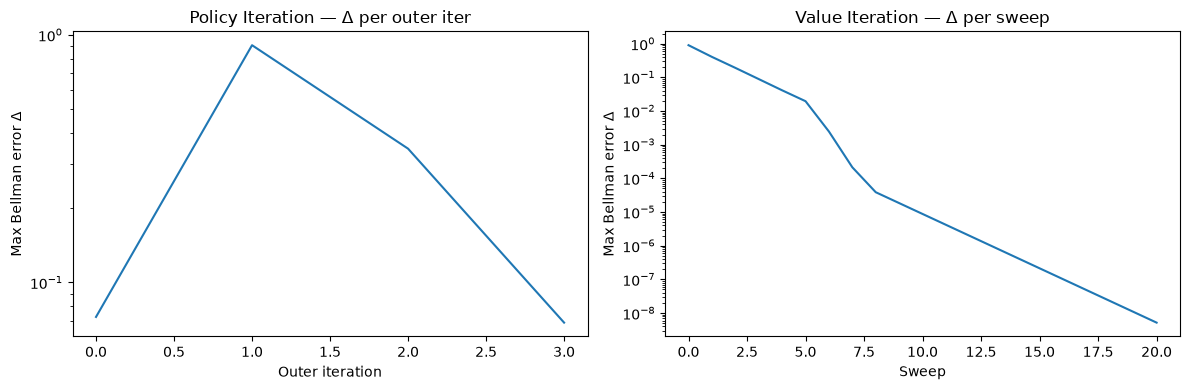

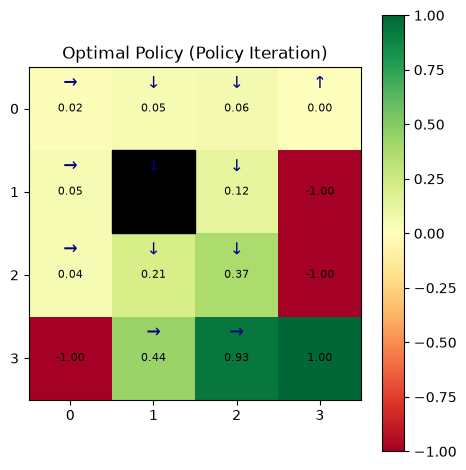

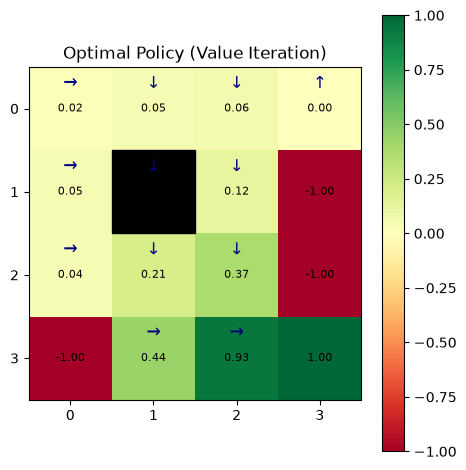

In [66]:
# NOTE: To make this work, your policy_iteration and value_iteration functions must
# return convergence delta histories. Modify them to also return deltas, or store them
# as attributes on the return value, then plot here.
#
# Expected plot: value_iteration shows a smooth exponential decay.
# Policy iteration shows a small number of points (one per outer iteration).

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO: plot deltas from policy_iteration on axes[0]
# TODO: plot deltas from value_iteration on axes[1]

axes[0].plot(delta_policy)
axes[0].set_title("Policy Iteration — Δ per outer iter")
axes[0].set_xlabel("Outer iteration")
axes[0].set_ylabel("Max Bellman error Δ")
axes[0].set_yscale("log")

axes[1].plot(delta_value)
axes[1].set_title("Value Iteration — Δ per sweep")
axes[1].set_xlabel("Sweep")
axes[1].set_ylabel("Max Bellman error Δ")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

# --- Visualize optimal policy ---
env.visualize_values(V_pi, policy_pi, "Optimal Policy (Policy Iteration)")
env.visualize_values(V_vi, policy_vi, "Optimal Policy (Value Iteration)")

## Part 6: Ablations

**Ablation 1:** Compare policy iteration vs value iteration on a larger grid (8×8 or 10×10).
Which is faster in wall-clock time? Does the gap match your expectations from the lecture notes?

In [ ]:
# TODO: Create an 8x8 GridWorld with a few walls and holes.
# Run both algorithms and compare timing. Print results.

**Observation (fill in):** On the larger grid, ___ is faster because ___.

In [ ]:
# Ablation 2: Effect of theta on solution quality
# TODO: Run value_iteration with theta in [1e-2, 1e-4, 1e-8].
# For each theta, measure: number of sweeps, max error vs the theta=1e-8 solution.
# Plot a table or bar chart.

**Observation (fill in):** Looser theta (larger value) requires ___ sweeps and introduces
___ error in the value function.

## Part 7: Reflection

Answer the questions below in the markdown cell provided.

1. Policy iteration converges in few outer iterations. Why does this not mean it is always
   faster than value iteration? (Think about what each outer iteration costs.)
2. In RLHF PPO, the critic $V^\pi(s)$ is updated using TD(0): a one-step Bellman backup.
   How does this relate to value iteration? What is "missing" compared to full DP?
3. The Bellman optimality operator is a $\gamma$-contraction. If $\gamma = 0.5$, how many
   value iteration sweeps are needed to reduce the initial error by a factor of $10^6$?
   (Hint: solve $0.5^k < 10^{-6}$.)

In [ ]:
# Your answers here (markdown cell below)

**Answers:**
1.
2.
3.